In [ ]:
import sys
from pathlib import Path

import numpy as np
from river.decomposition import OnlineDMD, OnlineSVD
from river.preprocessing import Hankelizer
from tqdm import tqdm

sys.path.append("../")
from functions.chdsubid import SubIDChangeDetector
from functions.datasets import load_nprs43, load_nprs44
from functions.plot import plot_chd
from functions.rolling import Rolling

In [ ]:
%load_ext autoreload
%autoreload 2

Snapshots processed:   0%|          | 0/6500 [00:00<?, ?it/s]

Snapshots processed:   9%|▉         | 576/6500 [00:01<00:10, 571.90it/s]

Snapshots processed:  18%|█▊        | 1148/6500 [00:04<00:20, 263.36it/s]

Snapshots processed:  23%|██▎       | 1496/6500 [00:05<00:20, 245.52it/s]

Snapshots processed:  27%|██▋       | 1784/6500 [00:07<00:20, 232.22it/s]

...

Snapshots processed:  90%|█████████ | 5866/6500 [00:34<00:05, 126.52it/s]

Snapshots processed:  93%|█████████▎| 6057/6500 [00:35<00:03, 141.84it/s]

Snapshots processed:  96%|█████████▌| 6209/6500 [00:37<00:02, 129.70it/s]

Snapshots processed:  98%|█████████▊| 6347/6500 [00:38<00:01, 114.56it/s]

Snapshots processed: 100%|██████████| 6500/6500 [00:39<00:00, 163.96it/s]

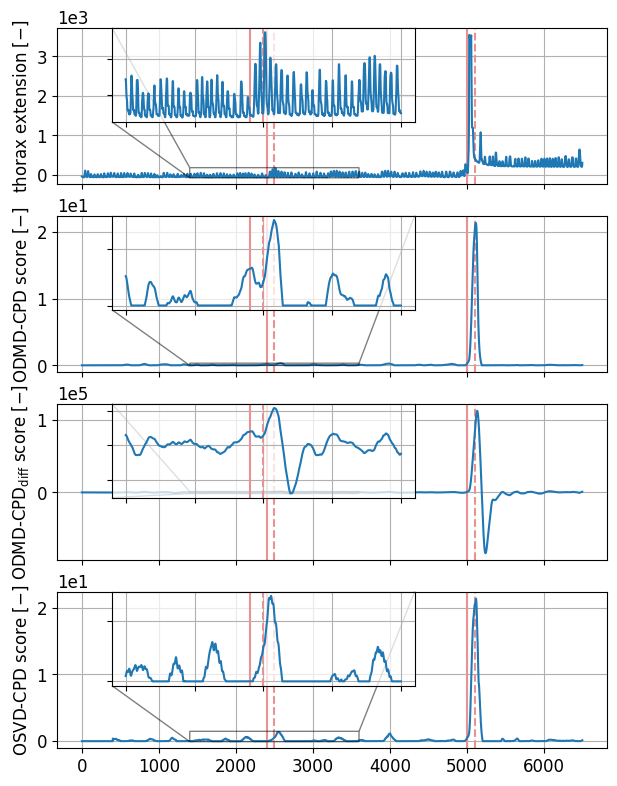

In [ ]:
# [donotremove]
# Read data
X = load_nprs44()[15500:22000]

# Initialize Parameters
# Kawahara 2007 parameters
window_size = 300
hn = 80
ref_size = 100
test_size = 100
r = 2

# Initialize Hankelizer
hankelizer = Hankelizer(hn)

# Initialize Transformer
init_size = window_size
odmd = Rolling(
    OnlineDMD(
        r=r,
        initialize=init_size,
        w=1.0,
        exponential_weighting=False,
        eig_rtol=1e-1,
    ),
    init_size + 1,
)
# Ref
osvd = OnlineSVD(r, initialize=init_size, force_orth=False)
# Initialize Change-Point Detector
subid_dmd = SubIDChangeDetector(
    odmd,
    ref_size=ref_size,
    test_size=test_size,
    grace_period=init_size + test_size + 1,
)
# Ref
subid_svd = SubIDChangeDetector(
    osvd,
    ref_size=ref_size,
    test_size=test_size,
    grace_period=init_size + test_size + 1,
)

# Build pipeline
pipeline_dmd = hankelizer | subid_dmd
pipeline_svd = Hankelizer(hn) | subid_svd

# Prepare arrays for storing results
scores_dmd = np.zeros(X.shape[0], dtype=float)
scores_svd = np.zeros(X.shape[0], dtype=float)
scores_dmd_diff = np.zeros(X.shape[0], dtype=complex)
dist = np.zeros((X.shape[0], 2), dtype=complex)
modes = np.empty((X.shape[0], hn, r), dtype=complex)
mean_modes = np.empty(X.shape[0], dtype=complex)
svs = np.zeros((X.shape[0], r, r), dtype=float)
us = np.zeros((X.shape[0], hn, r), dtype=float)
As = np.zeros((X.shape[0], r, r), dtype=float)

# Run pipeline
for i, (x) in tqdm(
    enumerate(X),
    total=len(X),
    mininterval=1.0,
    desc="Snapshots processed",
):
    scores_dmd[i] = pipeline_dmd.score_one({"x": x})
    scores_svd[i] = pipeline_svd.score_one({"x": x})
    dist[i, :] = subid_dmd.distances
    scores_dmd_diff[i] = dist[i, 1] - dist[i, 0]

    pipeline_dmd.learn_one({"x": x})
    pipeline_svd.learn_one({"x": x})

    if subid_dmd.n_seen > window_size + test_size:
        modes[i, :, :] = odmd.modes
        mean_modes[i] = modes[i, :, :].mean()
        svs[i, :, :] = odmd._svd._S
        us[i, :, :] = odmd._svd._U
        As[i, :, :] = odmd.A

# Plot results
fig, axs = plot_chd(
    {
        "thorax extension $[-]$": X,
        "ODMD-CPD score [$-$]": scores_dmd.real,
        "ODMD-CPD$_\\mathrm{diff}$ score [$-$]": scores_dmd_diff.real,
        "OSVD-CPD score [$-$]": scores_svd.real,
    },
    [2400, 5000],
    grace_period=test_size,
    ids_in_start=[1500],  # Original 16190
    ids_in_end=[3500],  # Original 16344
)

fig_name = (
    f"results/.nprs/nprs44-chd_r{r}-"
    f"{f'roll_{odmd.window_size}' if isinstance(odmd, Rolling) else 'noroll'}-"
    f"dmd_w{odmd.w}-h{hn}.pdf"
)
Path(fig_name).parent.mkdir(parents=True, exist_ok=True)
fig.savefig(fig_name)

Snapshots processed:   0%|          | 0/4000 [00:00<?, ?it/s]

Snapshots processed:  14%|█▍        | 564/4000 [00:01<00:06, 562.22it/s]

Snapshots processed:  28%|██▊       | 1127/4000 [00:04<00:12, 231.80it/s]

Snapshots processed:  36%|███▋      | 1456/4000 [00:08<00:16, 149.68it/s]

Snapshots processed:  42%|████▏     | 1674/4000 [00:09<00:15, 152.20it/s]

...

Snapshots processed:  89%|████████▊ | 3549/4000 [00:23<00:03, 130.37it/s]

Snapshots processed:  92%|█████████▏| 3692/4000 [00:24<00:02, 131.90it/s]

Snapshots processed:  96%|█████████▌| 3833/4000 [00:25<00:01, 129.81it/s]

Snapshots processed:  99%|█████████▉| 3969/4000 [00:27<00:00, 111.97it/s]

Snapshots processed: 100%|██████████| 4000/4000 [00:27<00:00, 146.42it/s]

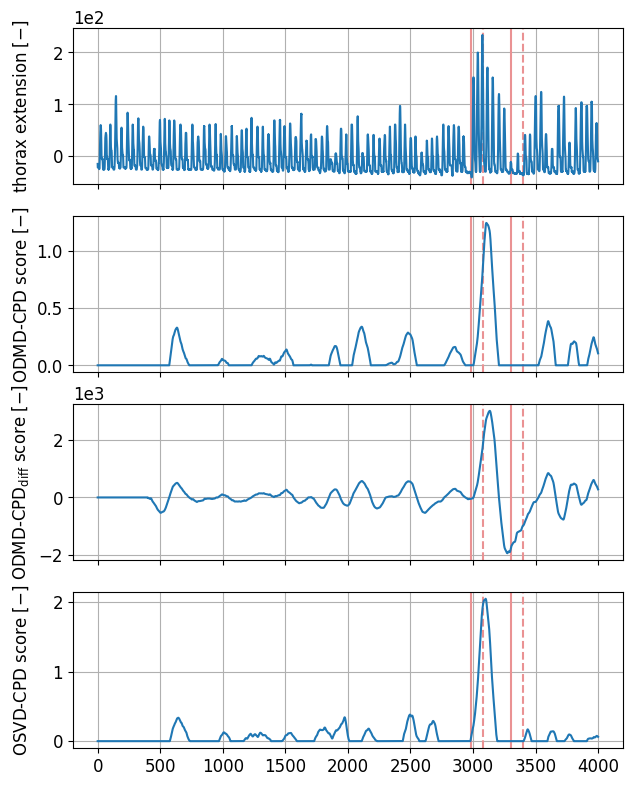

In [ ]:
# [donotremove]
# Read data
X = load_nprs43()[10000:14000]

# Initialize Parameters
# Kawahara 2007 parameters
window_size = 300
hn = 80
ref_size = 100
test_size = 100
r = 2

# Initialize Hankelizer
hankelizer = Hankelizer(hn)

# Initialize Transformer
init_size = window_size
odmd = Rolling(
    OnlineDMD(
        r=r,
        initialize=init_size,
        w=1.0,
        exponential_weighting=False,
        eig_rtol=1e-1,
    ),
    init_size + 1,
)
# Ref
osvd = OnlineSVD(r, initialize=init_size, force_orth=False)
# Initialize Change-Point Detector
subid_dmd = SubIDChangeDetector(
    odmd,
    ref_size=ref_size,
    test_size=test_size,
    grace_period=init_size + test_size + 1,
)
# Ref
subid_svd = SubIDChangeDetector(
    osvd,
    ref_size=ref_size,
    test_size=test_size,
    grace_period=init_size + test_size + 1,
)

# Build pipeline
pipeline_dmd = hankelizer | subid_dmd
pipeline_svd = Hankelizer(hn) | subid_svd

# Prepare arrays for storing results
scores_dmd = np.zeros(X.shape[0], dtype=float)
scores_svd = np.zeros(X.shape[0], dtype=float)
scores_dmd_diff = np.zeros(X.shape[0], dtype=complex)
dist = np.zeros((X.shape[0], 2), dtype=complex)
modes = np.empty((X.shape[0], hn, r), dtype=complex)
mean_modes = np.empty(X.shape[0], dtype=complex)
svs = np.zeros((X.shape[0], r, r), dtype=float)
us = np.zeros((X.shape[0], hn, r), dtype=float)
As = np.zeros((X.shape[0], r, r), dtype=float)

# Run pipeline
for i, (x) in tqdm(
    enumerate(X),
    total=len(X),
    mininterval=1.0,
    desc="Snapshots processed",
):
    scores_dmd[i] = pipeline_dmd.score_one({"x": x})
    scores_svd[i] = pipeline_svd.score_one({"x": x})
    dist[i, :] = subid_dmd.distances
    scores_dmd_diff[i] = dist[i, 1] - dist[i, 0]

    pipeline_dmd.learn_one({"x": x})
    pipeline_svd.learn_one({"x": x})

    if subid_dmd.n_seen > window_size + test_size:
        modes[i, :, :] = odmd.modes
        mean_modes[i] = modes[i, :, :].mean()
        svs[i, :, :] = odmd._svd._S
        us[i, :, :] = odmd._svd._U
        As[i, :, :] = odmd.A

# Plot results
fig, axs = plot_chd(
    {
        "thorax extension $[-]$": X,
        "ODMD-CPD score [$-$]": scores_dmd.real,
        "ODMD-CPD$_\\mathrm{diff}$ score [$-$]": scores_dmd_diff.real,
        "OSVD-CPD score [$-$]": scores_svd.real,
    },
    [2980, 3300],
    grace_period=test_size,
)

fig_name = (
    f"results/.nprs/nprs43-chd_r{r}-"
    f"{f'roll_{odmd.window_size}' if isinstance(odmd, Rolling) else 'noroll'}-"
    f"dmd_w{odmd.w}-h{hn}.pdf"
)
Path(fig_name).parent.mkdir(parents=True, exist_ok=True)
fig.savefig(fig_name)